# Zenodo Dataset — Model Evaluation & Cross-Dataset Comparison

**Dataset:** KU Leuven Blackboard LMS (Tiukhova et al., 2024)  
**Zenodo record:** [17087849](https://zenodo.org/records/17087849)  
**Pipeline version:** `v2_corrected`  
**Prediction window:** Week 8 (56 days)

This notebook presents GNN and LightGBM evaluation results on the Zenodo dataset and
directly compares them to OULAD results. It mirrors the structure of
`OULAD_Baseline_Analysis.ipynb`.

All results were generated by `src/run_zenodo_pipeline.py` and
`src/run_zenodo_lgbm_only.py` and stored in `results/zenodo/`.


## 0. Setup

In [1]:
import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Image, Markdown
warnings.filterwarnings("ignore")

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT / "src"))

ZENODO_DIR = PROJECT_ROOT / "results" / "zenodo"
GRAPH_DIR  = PROJECT_ROOT / "results" / "graph"

sns.set_theme(style="whitegrid")
ATRISK  = "#e74c3c"
SUCCESS = "#3b82d4"
ACCENT  = "#7c5cd8"

print("Project root:", PROJECT_ROOT)


Project root: /Users/olivialoza/Documents/Development/OULAD


## 1. Load Zenodo Results

In [2]:
zen_gnn_rand  = pd.read_csv(ZENODO_DIR / "random_student_results.csv")
zen_lgbm      = pd.read_csv(ZENODO_DIR / "comparison_results.csv")
zen_lcpo_raw  = pd.read_csv(ZENODO_DIR / "lcpo_results.csv")
zen_lcpo_sum  = pd.read_csv(ZENODO_DIR / "lcpo_summary.csv")

lgbm_rand = zen_lgbm[zen_lgbm["split_type"] == "random_student"].copy()
lgbm_lcpo = zen_lgbm[zen_lgbm["split_type"] == "lcpo"].copy()

print(f"GNN random-split rows  : {len(zen_gnn_rand)}")
print(f"GNN LCPO rows          : {len(zen_lcpo_raw)}  ({zen_lcpo_raw['fold_idx'].nunique()} folds × {zen_lcpo_raw['model_seed'].nunique()} seeds)")
print(f"LightGBM random rows   : {len(lgbm_rand)}")
print(f"LightGBM LCPO rows     : {len(lgbm_lcpo)}")


GNN random-split rows  : 5
GNN LCPO rows          : 30  (6 folds × 5 seeds)
LightGBM random rows   : 5
LightGBM LCPO rows     : 6


## 2. GNN Random-Student Split Results

EnrollmentGNN with weighted loss, run across 5 random seeds.
Features: VLE interactions only (no assessment, no student demographics — schema gaps).


In [3]:
metrics = ["auroc", "auprc", "f1", "precision", "recall", "balanced_acc"]
print("GNN random-split (5 seeds):")
display(zen_gnn_rand[["seed", "model"] + metrics + ["best_epoch"]].round(4))

print()
print("Summary (mean ± std):")
for m in metrics:
    vals = zen_gnn_rand[m]
    print(f"  {m:20s}: {vals.mean():.4f} ± {vals.std():.4f}")


GNN random-split (5 seeds):


,seed,model,auroc,auprc,f1,precision,recall,balanced_acc,best_epoch
0,42,EnrollmentGNN,0.5635,0.4089,0.4827,0.3433,0.8127,0.5190,91
1,123,EnrollmentGNN,0.5968,0.4580,0.4842,0.3723,0.6923,0.5271,95
2,7,EnrollmentGNN,0.5176,0.3546,0.4820,0.3347,0.8606,0.5063,69
3,17,EnrollmentGNN,0.5245,0.3901,0.4756,0.4128,0.5607,0.5510,0
4,99,EnrollmentGNN,0.5672,0.4091,0.5119,0.3440,1.0000,0.5026,39



Summary (mean ± std):
  auroc               : 0.5539 ± 0.0327
  auprc               : 0.4041 ± 0.0374
  f1                  : 0.4873 ± 0.0142
  precision           : 0.3614 ± 0.0320
  recall              : 0.7853 ± 0.1670
  balanced_acc        : 0.5212 ± 0.0193


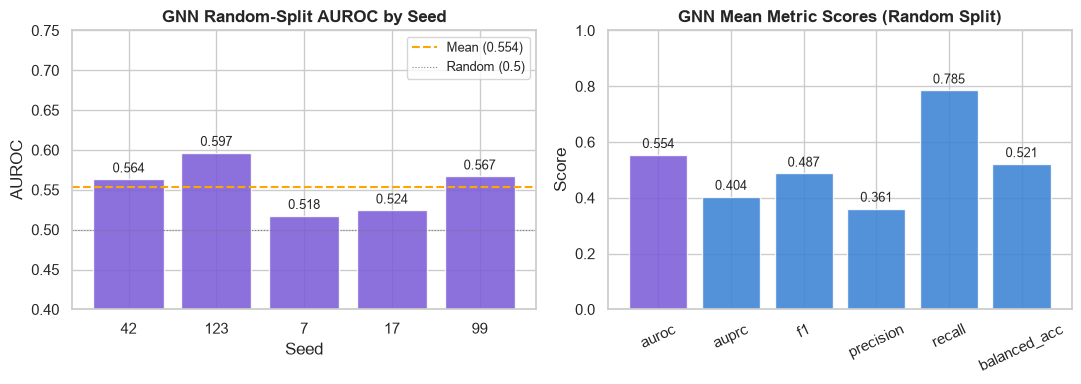

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# AUROC per seed
ax = axes[0]
bars = ax.bar(zen_gnn_rand["seed"].astype(str), zen_gnn_rand["auroc"],
              color=ACCENT, edgecolor="white", alpha=0.88)
ax.axhline(zen_gnn_rand["auroc"].mean(), color="orange", lw=1.5, linestyle="--",
           label=f"Mean ({zen_gnn_rand['auroc'].mean():.3f})")
ax.axhline(0.5, color="grey", lw=0.8, linestyle=":", label="Random (0.5)")
ax.set_xlabel("Seed")
ax.set_ylabel("AUROC")
ax.set_ylim(0.4, 0.75)
ax.set_title("GNN Random-Split AUROC by Seed", fontweight="bold")
ax.legend(fontsize=9)
for bar, val in zip(bars, zen_gnn_rand["auroc"]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f"{val:.3f}", ha="center", va="bottom", fontsize=9)

# Metric comparison
ax = axes[1]
mean_metrics = zen_gnn_rand[metrics].mean()
colors = [ACCENT if m == "auroc" else SUCCESS for m in metrics]
bars2 = ax.bar(metrics, mean_metrics, color=colors, edgecolor="white", alpha=0.88)
ax.set_ylabel("Score")
ax.set_ylim(0, 1.0)
ax.set_title("GNN Mean Metric Scores (Random Split)", fontweight="bold")
ax.tick_params(axis="x", rotation=25)
for bar, val in zip(bars2, mean_metrics):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.015,
            f"{val:.3f}", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.show()


## 3. GNN LCPO Results — Leave-Course-Presentation-Out

6 held-out folds (one per course-presentation), each evaluated across 5 model seeds.
LCPO measures whether the GNN generalises to a course-presentation it has never seen.


In [5]:
zen_lcpo_sum["course_pres"] = (
    zen_lcpo_sum["held_out_module"] + " / " +
    zen_lcpo_sum["held_out_presentation"].astype(str).str.rstrip(".0")
)
print("GNN LCPO summary (mean ± std over 5 seeds):")
display(zen_lcpo_sum[["course_pres", "auroc_mean", "auroc_std",
                       "f1_mean", "f1_std", "balanced_acc_mean"]].round(4))
print(f"\nOverall LCPO AUROC: {zen_lcpo_sum['auroc_mean'].mean():.4f} ± {zen_lcpo_sum['auroc_mean'].std():.4f}")


GNN LCPO summary (mean ± std over 5 seeds):


,course_pres,auroc_mean,auroc_std,f1_mean,f1_std,balanced_acc_mean
0,Accountancy / 1819,0.5125,0.0201,0.2695,0.1511,0.5021
1,Accountancy / 192,0.4833,0.0197,0.0000,0.0000,0.5000
2,Accountancy / 2021,0.4830,0.0222,0.0000,0.0000,0.4988
3,Global economics / 1819,0.5031,0.0169,0.4782,0.1838,0.5051
4,Global economics / 192,0.5150,0.0403,0.3941,0.0004,0.5004
5,Global economics / 2021,0.4950,0.0430,0.4523,0.1367,0.5162



Overall LCPO AUROC: 0.4986 ± 0.0140


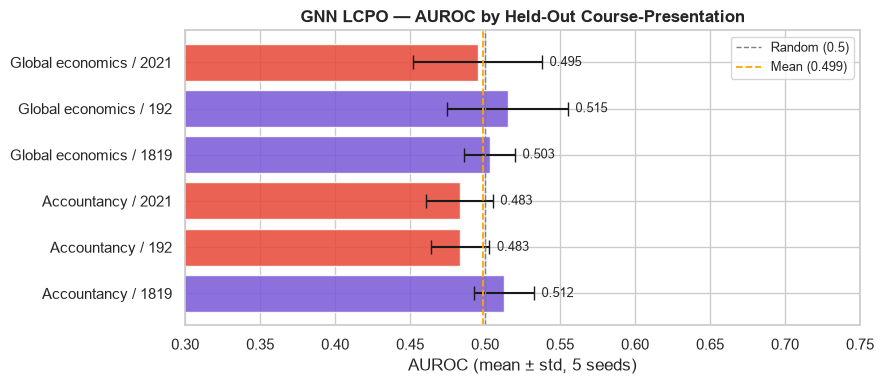

In [6]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.barh(zen_lcpo_sum["course_pres"], zen_lcpo_sum["auroc_mean"],
        xerr=zen_lcpo_sum["auroc_std"], capsize=5,
        color=[ATRISK if v < 0.50 else ACCENT for v in zen_lcpo_sum["auroc_mean"]],
        alpha=0.88, edgecolor="white")
ax.axvline(0.5, color="grey", lw=1.0, linestyle="--", label="Random (0.5)")
ax.axvline(zen_lcpo_sum["auroc_mean"].mean(), color="orange", lw=1.3, linestyle="--",
           label=f"Mean ({zen_lcpo_sum['auroc_mean'].mean():.3f})")
ax.set_xlabel("AUROC (mean ± std, 5 seeds)")
ax.set_xlim(0.3, 0.75)
ax.set_title("GNN LCPO — AUROC by Held-Out Course-Presentation", fontweight="bold")
ax.legend(fontsize=9)
for i, row in zen_lcpo_sum.iterrows():
    ax.text(row["auroc_mean"] + row["auroc_std"] + 0.005, i,
            f"{row['auroc_mean']:.3f}", va="center", fontsize=9)
plt.tight_layout()
plt.show()


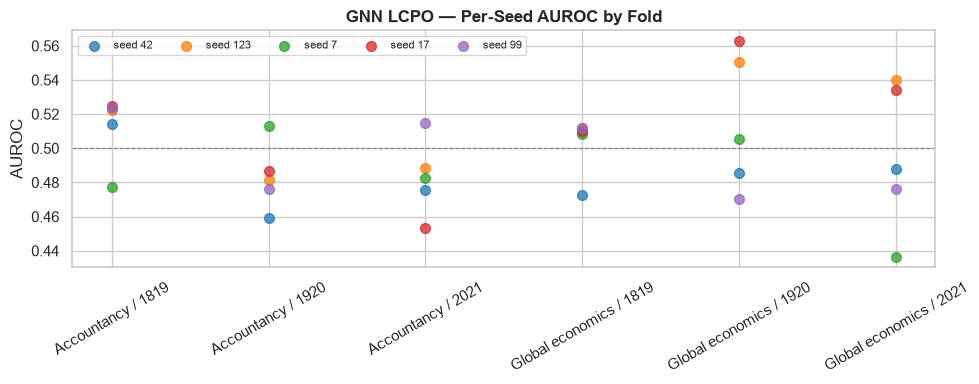

In [7]:
# Per-seed scatter: fold vs AUROC
fig, ax = plt.subplots(figsize=(10, 4))
seeds = zen_lcpo_raw["model_seed"].unique()
palette = sns.color_palette("tab10", n_colors=len(seeds))
for seed, col in zip(seeds, palette):
    sub = zen_lcpo_raw[zen_lcpo_raw["model_seed"] == seed].copy()
    sub["course_pres"] = sub["held_out_module"] + " / " + sub["held_out_presentation"].astype(str)
    ax.scatter(sub["course_pres"], sub["auroc"], color=col, label=f"seed {seed}",
               alpha=0.75, s=50, zorder=3)
ax.axhline(0.5, color="grey", lw=0.8, linestyle="--")
ax.set_ylabel("AUROC")
ax.set_title("GNN LCPO — Per-Seed AUROC by Fold", fontweight="bold")
ax.tick_params(axis="x", rotation=30)
ax.legend(fontsize=8, ncol=5)
plt.tight_layout()
plt.show()


## 4. LightGBM Baseline Results (VLE-only features)

LightGBM uses `vle_total`, `vle_mean`, `vle_std` features — the same three features
available to the GNN (no assessment data, no demographics). This makes the
GNN–LightGBM comparison on equal feature footing.


In [8]:
print("=== LightGBM Random-Split (5 seeds) ===")
display(lgbm_rand[["fold_or_seed", "auroc", "auprc", "f1", "precision", "recall"]].round(4))
print(f"Mean AUROC: {lgbm_rand['auroc'].mean():.4f} ± {lgbm_rand['auroc'].std():.4f}")

print()
print("=== LightGBM LCPO (6 folds) ===")
display(lgbm_lcpo[["fold_or_seed", "held_out_module", "held_out_presentation",
                    "auroc", "auprc", "f1"]].round(4))
print(f"Mean AUROC: {lgbm_lcpo['auroc'].mean():.4f} ± {lgbm_lcpo['auroc'].std():.4f}")


=== LightGBM Random-Split (5 seeds) ===


,fold_or_seed,auroc,auprc,f1,precision,recall
0,42,0.6507,0.4681,0.5082,0.3492,0.9329
1,123,0.6214,0.4620,0.5256,0.3983,0.7726
2,7,0.6383,0.4756,0.5299,0.3917,0.8188
3,17,0.6725,0.5307,0.5706,0.4176,0.9003
4,99,0.6478,0.4599,0.5435,0.4032,0.8333


Mean AUROC: 0.6461 ± 0.0187

=== LightGBM LCPO (6 folds) ===


,fold_or_seed,held_out_module,held_out_presentation,auroc,auprc,f1
5,0,Accountancy,1819.0,0.6221,0.4176,0.4794
6,1,Accountancy,1920.0,0.6347,0.4541,0.4859
7,2,Accountancy,2021.0,0.5831,0.4047,0.2828
8,3,Global economics,1819.0,0.5612,0.5085,0.6133
9,4,Global economics,1920.0,0.6348,0.3276,0.3523
10,5,Global economics,2021.0,0.6057,0.5573,0.4828


Mean AUROC: 0.6069 ± 0.0298


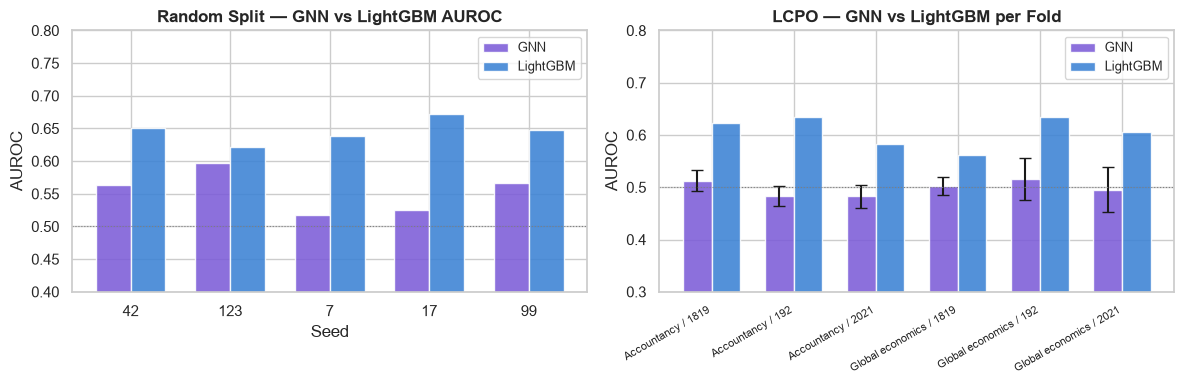

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Random-split: GNN vs LightGBM
ax = axes[0]
gnn_aurocs  = zen_gnn_rand["auroc"].values
lgbm_aurocs = lgbm_rand["auroc"].values
x = np.arange(len(gnn_aurocs))
w = 0.35
ax.bar(x - w/2, gnn_aurocs, w, label="GNN",      color=ACCENT, alpha=0.88, edgecolor="white")
ax.bar(x + w/2, lgbm_aurocs[:len(gnn_aurocs)], w, label="LightGBM", color=SUCCESS, alpha=0.88, edgecolor="white")
ax.set_xticks(x)
ax.set_xticklabels([str(s) for s in zen_gnn_rand["seed"]])
ax.set_xlabel("Seed"); ax.set_ylabel("AUROC")
ax.set_ylim(0.4, 0.80)
ax.axhline(0.5, color="grey", lw=0.8, linestyle=":")
ax.set_title("Random Split — GNN vs LightGBM AUROC", fontweight="bold")
ax.legend(fontsize=9)

# LCPO: GNN vs LightGBM per fold
ax = axes[1]
fold_labels = zen_lcpo_sum["course_pres"].tolist()
gnn_lcpo_m  = zen_lcpo_sum["auroc_mean"].values
gnn_lcpo_s  = zen_lcpo_sum["auroc_std"].values
lgbm_lcpo_v = lgbm_lcpo["auroc"].values
x2 = np.arange(len(fold_labels))
ax.bar(x2 - w/2, gnn_lcpo_m,  w, yerr=gnn_lcpo_s,  capsize=4, label="GNN",      color=ACCENT, alpha=0.88, edgecolor="white")
ax.bar(x2 + w/2, lgbm_lcpo_v, w,                    label="LightGBM", color=SUCCESS, alpha=0.88, edgecolor="white")
ax.set_xticks(x2)
ax.set_xticklabels(fold_labels, rotation=30, ha="right", fontsize=8)
ax.set_ylabel("AUROC"); ax.set_ylim(0.3, 0.80)
ax.axhline(0.5, color="grey", lw=0.8, linestyle=":")
ax.set_title("LCPO — GNN vs LightGBM per Fold", fontweight="bold")
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()


## 5. Cross-Dataset Comparison — Zenodo vs. OULAD

OULAD results are from `results/graph/comparison_results.csv`
(`pipeline_version = "v2_corrected"`). Both datasets use Week 8 (56-day window).

**Note on comparability:** The Zenodo GNN uses 3 edge types (vs 5 for OULAD)
and constant student features (vs 11 demographic features). The performance gap
reflects missing feature modalities, not a pipeline regression.


In [10]:
# Load OULAD results
oulad_comp = pd.read_csv(GRAPH_DIR / "comparison_results.csv")
w8 = oulad_comp[oulad_comp["week"] == 8].copy()

def summary(df, model_filter, split):
    sub = df[(df["model"].str.contains(model_filter, case=False)) & (df["split_type"] == split)]
    if sub.empty:
        return "—"
    return f"{sub['auroc'].mean():.3f} ± {sub['auroc'].std():.3f}"

cross = pd.DataFrame([
    ("OULAD",  "GNN (weighted)",  "random_student",
     summary(w8, "GNN \(weighted\)", "random_student"),
     summary(w8, "GNN \(weighted\)", "lcpo")),
    ("OULAD",  "LightGBM",        "—",
     summary(w8, "LightGBM", "random_student"),
     summary(w8, "LightGBM", "lcpo")),
    ("Zenodo", "GNN",             "random_student",
     f"{zen_gnn_rand['auroc'].mean():.3f} ± {zen_gnn_rand['auroc'].std():.3f}",
     f"{zen_lcpo_sum['auroc_mean'].mean():.3f} ± {zen_lcpo_sum['auroc_mean'].std():.3f}"),
    ("Zenodo", "LightGBM (VLE-only)", "—",
     f"{lgbm_rand['auroc'].mean():.3f} ± {lgbm_rand['auroc'].std():.3f}",
     f"{lgbm_lcpo['auroc'].mean():.3f} ± {lgbm_lcpo['auroc'].std():.3f}"),
], columns=["Dataset", "Model", "Feature set", "AUROC Random", "AUROC LCPO"])

print("Cross-Dataset AUROC Summary (Week 8)")
pd.set_option("display.max_colwidth", None)
display(cross)


Cross-Dataset AUROC Summary (Week 8)


,Dataset,Model,Feature set,AUROC Random,AUROC LCPO
0,OULAD,GNN (weighted),random_student,0.837 ± 0.003,—
1,OULAD,LightGBM,—,0.765 ± 0.005,0.775 ± 0.056
2,Zenodo,GNN,random_student,0.554 ± 0.033,0.499 ± 0.014
3,Zenodo,LightGBM (VLE-only),—,0.646 ± 0.019,0.607 ± 0.030


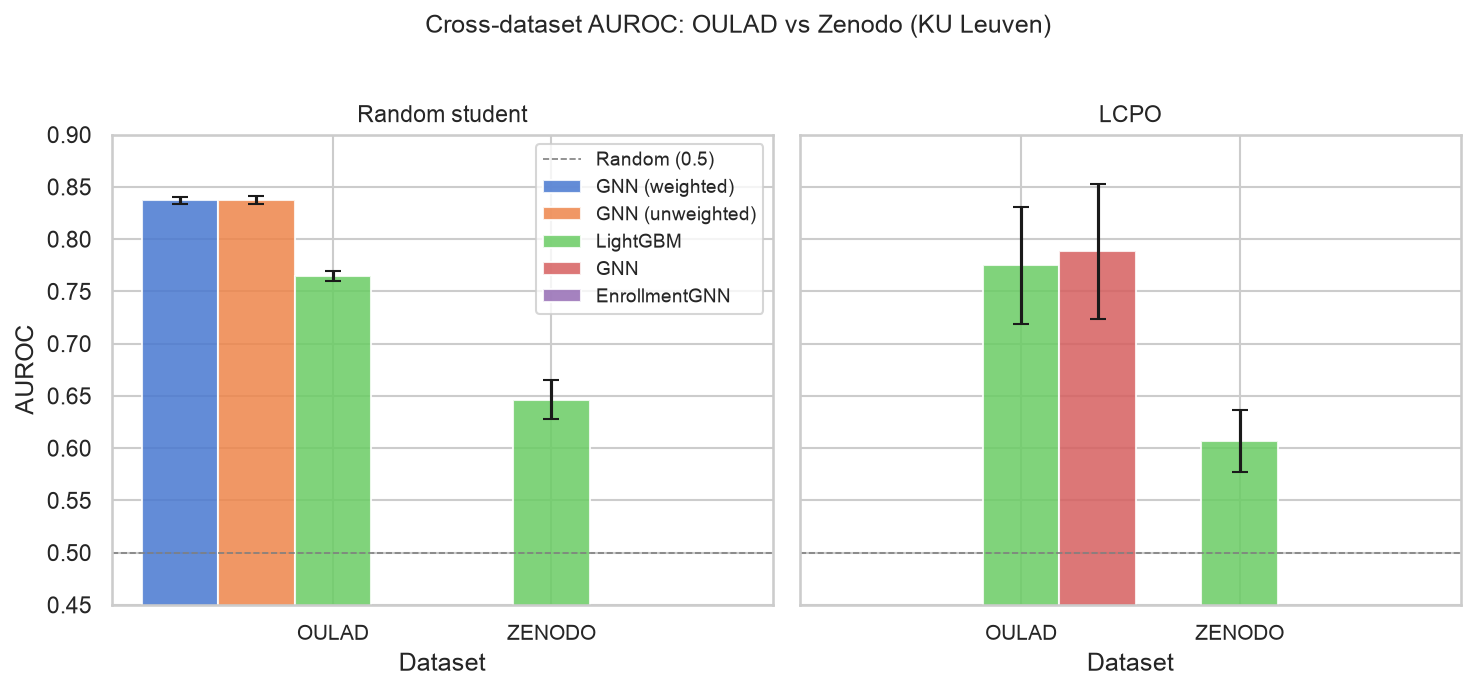

In [11]:
# Cross-dataset figure from generate_report_figures.py
fig_path = GRAPH_DIR / "figures" / "fig_cross_dataset.png"
if fig_path.exists():
    display(Image(str(fig_path), width=950))
else:
    print(f"Figure not found: {fig_path}")
    print("Run: python src/generate_report_figures.py")


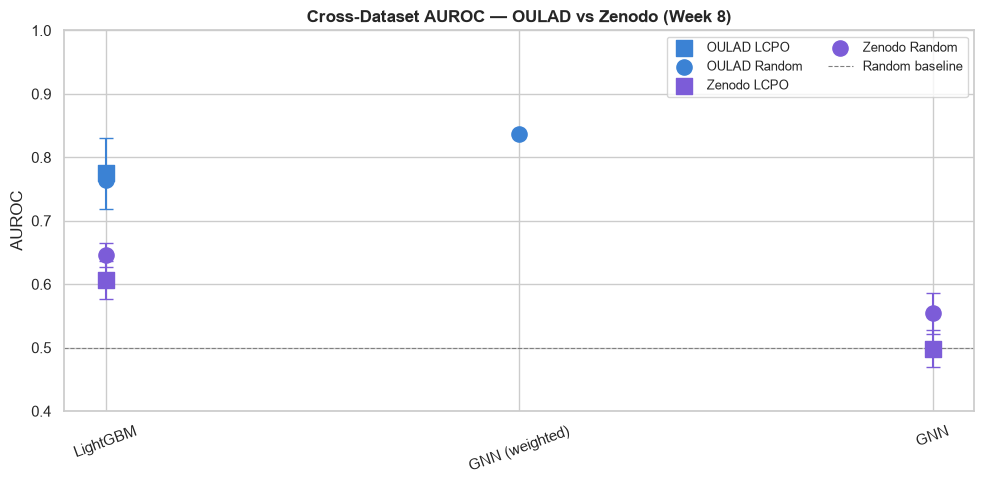

In [12]:
# Combined AUROC dot-plot: all models, both datasets, both splits
rows = []
for split, label in [("random_student", "Random"), ("lcpo", "LCPO")]:
    for ds, model, aurocs in [
        ("OULAD",  "GNN (weighted)",     w8[(w8["split_type"]==split) & (w8["model"]=="GNN (weighted)")]["auroc"]),
        ("OULAD",  "LightGBM",           w8[(w8["split_type"]==split) & (w8["model"]=="LightGBM")]["auroc"]),
        ("Zenodo", "GNN",                zen_gnn_rand["auroc"] if split=="random_student" else zen_lcpo_raw["auroc"]),
        ("Zenodo", "LightGBM",           lgbm_rand["auroc"] if split=="random_student" else lgbm_lcpo["auroc"]),
    ]:
        if len(aurocs):
            rows.append({"Dataset": ds, "Model": model, "Split": label,
                         "mean": aurocs.mean(), "std": aurocs.std()})

plot_df = pd.DataFrame(rows)

fig, ax = plt.subplots(figsize=(10, 5))
palette2 = {"OULAD": "#3b82d4", "Zenodo": "#7c5cd8"}
markers2 = {"Random": "o", "LCPO": "s"}
for (ds, split), grp in plot_df.groupby(["Dataset", "Split"]):
    ax.scatter(grp["Model"], grp["mean"],
               color=palette2[ds], marker=markers2[split], s=120,
               label=f"{ds} {split}", zorder=4)
    for _, row in grp.iterrows():
        ax.errorbar(row["Model"], row["mean"], yerr=row["std"],
                    fmt="none", color=palette2[ds], capsize=5, lw=1.5, zorder=3)

ax.axhline(0.5, color="grey", lw=0.8, linestyle="--", label="Random baseline")
ax.set_ylabel("AUROC")
ax.set_ylim(0.4, 1.0)
ax.set_title("Cross-Dataset AUROC — OULAD vs Zenodo (Week 8)", fontweight="bold")
ax.tick_params(axis="x", rotation=20)
ax.legend(fontsize=9, ncol=2)
plt.tight_layout()
plt.show()


## 6. Limitations & Schema Gaps

The following gaps between OULAD and Zenodo constrain direct comparability.
Full rationale is in [`docs/DESIGN_DECISIONS.md`](../docs/DESIGN_DECISIONS.md) §4
and [`docs/zenodo_dataset_feasibility.md`](../docs/zenodo_dataset_feasibility.md).

| Gap | OULAD | Zenodo | Impact |
|-----|-------|--------|--------|
| Assessment data | `submitted` + `contains_assess` edges | Absent | Cannot compare assessment-feature contribution; GNN uses VLE-only |
| Student demographics | 11 features (gender, age_band, IMD, etc.) | Absent | Student node features replaced by constant 1.0 placeholder |
| Dual temporal guard | `due_date ≤ window` AND `date_submitted ≤ window` | Single guard (`day_offset ≤ window`) | No assessment data → no leakage risk, but single guard differs methodologically |
| Timestamps | Pre-computed day offsets | Calendar datetimes | Offsets computed at query time from `course_info.json` |
| Dataset scale | 32,593 enrollments, 7 modules | 4,280 enrollments, 2 courses | GNN performance expected to be lower (less training signal) |
| LCPO folds | 22 (one per course-presentation) | 6 | Fewer folds → higher variance LCPO estimates |
| Prediction windows | Weeks 2, 4, 6, 8 | Week 8 only | Cross-dataset comparison limited to Week 8 |

> **Interpretation:** The Zenodo GNN AUROC (~0.55 random) vs OULAD (~0.84 random) gap
> is explained by the combined effect of smaller dataset, fewer edge types, and no
> student features. It does not indicate a pipeline regression.


## 7. Final Results Summary

In [13]:
summary_rows = [
    ("Zenodo", "GNN",      "Random-student", "5 seeds",
     f"{zen_gnn_rand['auroc'].mean():.3f} ± {zen_gnn_rand['auroc'].std():.3f}",
     f"{zen_gnn_rand['auprc'].mean():.3f} ± {zen_gnn_rand['auprc'].std():.3f}",
     f"{zen_gnn_rand['f1'].mean():.3f} ± {zen_gnn_rand['f1'].std():.3f}"),
    ("Zenodo", "GNN",      "LCPO",           "6 folds × 5 seeds",
     f"{zen_lcpo_raw['auroc'].mean():.3f} ± {zen_lcpo_raw['auroc'].std():.3f}",
     f"{zen_lcpo_raw['auprc'].mean():.3f} ± {zen_lcpo_raw['auprc'].std():.3f}",
     f"{zen_lcpo_raw['f1'].mean():.3f} ± {zen_lcpo_raw['f1'].std():.3f}"),
    ("Zenodo", "LightGBM", "Random-student", "5 seeds",
     f"{lgbm_rand['auroc'].mean():.3f} ± {lgbm_rand['auroc'].std():.3f}",
     f"{lgbm_rand['auprc'].mean():.3f} ± {lgbm_rand['auprc'].std():.3f}",
     f"{lgbm_rand['f1'].mean():.3f} ± {lgbm_rand['f1'].std():.3f}"),
    ("Zenodo", "LightGBM", "LCPO",           "6 folds",
     f"{lgbm_lcpo['auroc'].mean():.3f} ± {lgbm_lcpo['auroc'].std():.3f}",
     f"{lgbm_lcpo['auprc'].mean():.3f} ± {lgbm_lcpo['auprc'].std():.3f}",
     f"{lgbm_lcpo['f1'].mean():.3f} ± {lgbm_lcpo['f1'].std():.3f}"),
    ("OULAD",  "GNN (weighted)", "Random-student", "5 seeds",
     summary(w8, "GNN \(weighted\)", "random_student"),
     "—", "—"),
    ("OULAD",  "LightGBM", "Random-student", "5 seeds",
     summary(w8, "LightGBM", "random_student"),
     "—", "—"),
]

final = pd.DataFrame(summary_rows,
    columns=["Dataset", "Model", "Split", "N runs", "AUROC", "AUPRC", "F1"])
pd.set_option("display.max_colwidth", None)
display(final.style.set_properties(**{"text-align": "left"})
        .set_table_styles([{"selector": "th", "props": [("text-align", "left")]}]))


,Dataset,Model,Split,N runs,AUROC,AUPRC,F1
0,Zenodo,GNN,Random-student,5 seeds,0.554 ± 0.033,0.404 ± 0.037,0.487 ± 0.014
1,Zenodo,GNN,LCPO,6 folds × 5 seeds,0.499 ± 0.029,0.347 ± 0.074,0.266 ± 0.227
2,Zenodo,LightGBM,Random-student,5 seeds,0.646 ± 0.019,0.479 ± 0.029,0.536 ± 0.023
3,Zenodo,LightGBM,LCPO,6 folds,0.607 ± 0.030,0.445 ± 0.081,0.449 ± 0.116
4,OULAD,GNN (weighted),Random-student,5 seeds,0.837 ± 0.003,—,—
5,OULAD,LightGBM,Random-student,5 seeds,0.765 ± 0.005,—,—


---

*Notebook complete — `pipeline_version = "v2_corrected"`*  
*Results reproducible via `src/run_zenodo_pipeline.py` and `src/run_zenodo_lgbm_only.py`*
